# Avance de M0 por intervalos y reanudación desde estados corregidos

Primer notebook preparatorio del filtro de Kalman extendido (EKF). Se construye una función de avance del modelo
que después podrá usar el filtro:

```python
estado_siguiente, observables = advance_m0(estado_actual, tiempo_objetivo, entradas, theta, parametros_co2)
```

El notebook demuestra que:

1. Sin correcciones, el avance por intervalos reproduce la trayectoria de referencia de M0.
2. Una corrección artificial de biomasa (X +10 % a las 20 h) afecta correctamente las predicciones posteriores,
   recalculando las tasas desde los estados corregidos y no desde una trayectoria nominal precalculada.
3. La memoria de O₂ disuelto y del pool de CO₂ disuelto se conserva entre intervalos (no se reinicializan).

**Alcance.** Esta es una verificación numérica de la implementación. Quedan fuera: el EKF mismo, la estimación de
parámetros y las matrices P0/Q/R. El gate de activación se usa en su forma retrospectiva congelada (§2), construido
con química posterior; por lo tanto esta prueba no demuestra todavía funcionamiento online causal.

In [1]:
from __future__ import annotations

import json
import math
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from IPython import get_ipython
_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from IPython.display import display

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "fermentation_model").exists())
FM = ROOT / "fermentation_model"
LAB2026 = FM / "laboratory_2026"

for path in (FM, LAB2026, FM / "pilot_2025"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from shared import run_new_must_glycerol_estimability_doe as base
from shared import run_secondary_joint_campaign_doe as joint
from laboratory_2026 import run_estimability_historical_by_medium as natural_loader
from laboratory_2026 import run_co2_matrix_cross_validation_2026 as co2_cross
import run_pilot_2025_co2_solubility_integrated_doe as co2_model

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9.5})
pd.set_option("display.float_format", lambda v: f"{v:.6g}")

BIO_STATES = base.STATE_NAMES  # ("X", "Xd", "N", "G", "F", "E", "Gly")
IDX = {nombre: i for i, nombre in enumerate(BIO_STATES)}
UNIDADES = {"X": "kg/m3", "Xd": "kg/m3", "N": "kg/m3", "G": "g/L", "F": "g/L", "E": "g/L", "Gly": "g/L"}

WINDOW_END_H = 55.0        # ventana pre-pulso de LAB005
CORRECTION_TIME_H = 20.0   # instante de la corrección artificial de X
CORRECTION_X_FACTOR = 1.10
GRID_H = co2_cross.DRIVER_GRID_H

print("ROOT:", ROOT)
print(f"paso interno de M0: {GRID_H} h | ventana: 0–{WINDOW_END_H} h | corrección: X×{CORRECTION_X_FACTOR} a t = {CORRECTION_TIME_H} h")

ROOT: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe
paso interno de M0: 0.25 h | ventana: 0–55.0 h | corrección: X×1.1 a t = 20.0 h


## 1. Parámetros congelados

La capa cinética usa `theta_natural_full` completo (los 17 parámetros `FULL17`) tal como lo congela el holdout de
LAB019–LAB021. La capa de CO₂ usa la selección `state="C_full_theta_refit"`, `calibration_matrix="natural"` del
resultado `co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010`: es la misma referencia denominada
**M0_actual** en `lab019_021_co2_onset_effective_model_test`. No se usa el reajuste local M0_refit de ese notebook ni
los modelos M1/M2. Ningún parámetro se recalibra aquí.

In [2]:
HISTORICAL_CO2_DIR = (
    LAB2026 / "results" /
    "co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010"
)
THETA_FULL_PATH = LAB2026 / "results" / "estimability_historical_natural" / "theta_natural_full.csv"
CO2_PARAM_PATH = HISTORICAL_CO2_DIR / "three_state_co2_parameters.csv"

theta_table = pd.read_csv(THETA_FULL_PATH)
theta_full = dict(zip(theta_table["parameter"], theta_table["theta"].astype(float)))
assert set(base.FULL17) == set(theta_full) and len(theta_full) == 17

co2_parameter_table = pd.read_csv(CO2_PARAM_PATH)
co2_parameter_table = co2_parameter_table[
    co2_parameter_table["state"].eq("C_full_theta_refit")
    & co2_parameter_table["calibration_matrix"].eq("natural")
].copy()
parametros_co2 = dict(zip(co2_parameter_table["parameter"], co2_parameter_table["estimate"].astype(float)))
assert set(co2_cross.PARAMETER_BOUNDS).issubset(parametros_co2)

manifest = json.loads((HISTORICAL_CO2_DIR / "analysis_manifest.json").read_text(encoding="utf-8"))
procedencia = pd.DataFrame([
    ("theta cinético", "theta_natural_full.csv — 17 parámetros FULL17 (congelado)"),
    ("capa CO2 — run", manifest["experiment"]),
    ("capa CO2 — modelo", manifest["model"]),
    ("capa CO2 — seed / multistart", f"{manifest['seed']} / {manifest['n_starts']}"),
    ("capa CO2 — conversión sccm", str(manifest.get("sccm_conversion", {}).get("name", "n/d"))),
    ("capa CO2 — selección", "state=C_full_theta_refit, calibration_matrix=natural (M0_actual)"),
], columns=["elemento", "valor/versión"])
display(procedencia)

display(theta_table)
display(co2_parameter_table[["parameter", "estimate", "active_bound"]])

# Llamada congelada de M0_actual (idéntica a m0_grid_prediction del notebook de onset).
M0_PREDICT_KW = dict(
    k_release_h=parametros_co2["kCO2_release_h"],
    sat_scale=parametros_co2["CO2sat_scale"],
    o2_qmax_mg_gdw_h=parametros_co2["O2_qmax_mg_gdw_h"],
    o2_initial_scale=parametros_co2["O2_initial_scale"],
    chemistry_aligned=True,
    nitrogen_boost_transition=True,
    pulse_t_rise_h=parametros_co2["pulse_t_rise_h"],
    pulse_activity_gain=parametros_co2["pulse_activity_gain"],
    continuous_release=True,
    bounded_chemical_activation=True,
    chem_activation_start_fraction=parametros_co2["chem_activation_start_fraction"],
    chem_activation_duration_fraction=parametros_co2["chem_activation_duration_fraction"],
)

constantes_m0 = pd.DataFrame([
    ("O2_K_MG_L", co2_cross.O2_K_MG_L, "Michaelis del consumo de O2 [mg/L]"),
    ("O2_ANA_K_MG_L / O2_ANA_HILL", f"{co2_cross.O2_ANA_K_MG_L} / {co2_cross.O2_ANA_HILL}", "gate anaeróbico de M0"),
    ("O2_CRABTREE_FLOOR", co2_cross.O2_CRABTREE_FLOOR, "piso fermentativo de la fracción anaeróbica"),
    ("CO2_CONTINUOUS_RELEASE_FLOOR", co2_cross.CO2_CONTINUOUS_RELEASE_FLOOR, "piso de liberación continua"),
    ("CO2_G_PER_MG_O2_RESP", co2_model.CO2_G_PER_MG_O2_RESP, "CO2 respiratorio por mg de O2 [g/mg]"),
    ("CO2_G_PER_G_ETHANOL", joint.CO2_G_PER_G_ETHANOL, "CO2 por gramo de etanol producido [g/g]"),
    ("DRIVER_GRID_H", co2_cross.DRIVER_GRID_H, "paso interno de la capa CO2 [h]"),
    ("matrix_gain", parametros_co2["matrix_gain"], "escala empírica de observación: qobs = matrix_gain·qgas"),
], columns=["constante", "valor", "significado"])
display(constantes_m0)

,elemento,valor/versión
0,theta cinético,theta_natural_full.csv — 17 parámetros FULL17 ...
1,capa CO2 — run,co2_matrix_cross_validation_2026_full_theta_sc...
2,capa CO2 — modelo,solubility_o2_nitrogen_boost_continuous_release
3,capa CO2 — seed / multistart,20260812 / 5
4,capa CO2 — conversión sccm,SCCM_CORRECTED
5,capa CO2 — selección,"state=C_full_theta_refit, calibration_matrix=n..."


,parameter,theta,source
0,mu0,0.0787279,laboratory_2026\results\estimability_historica...
1,sN,8.75145,shared\results\new_must_glycerol_overnight_val...
2,qN,0.0210804,laboratory_2026\results\estimability_historica...
3,qXG,0.081491,shared\results\new_must_glycerol_overnight_val...
4,qXF,0.0709327,shared\results\new_must_glycerol_overnight_val...
5,betaG0,0.428878,laboratory_2026\results\estimability_historica...
6,sG,0.0974551,shared\results\new_must_glycerol_overnight_val...
7,betaF0,3.4404,laboratory_2026\results\estimability_historica...
8,sF,0.178295,shared\results\new_must_glycerol_overnight_val...
9,qEG,1.71281,laboratory_2026\results\estimability_historica...


,parameter,estimate,active_bound
45,kCO2_release_h,0.278349,False
46,CO2sat_scale,2.49891,True
47,O2_qmax_mg_gdw_h,0.253137,False
48,O2_initial_scale,0.179606,False
49,pulse_t_rise_h,56.7418,False
50,pulse_activity_gain,0.250011,True
51,chem_activation_start_fraction,0.741575,False
52,chem_activation_duration_fraction,0.457773,False
53,matrix_gain,1.60222,False


,constante,valor,significado
0,O2_K_MG_L,0.25,Michaelis del consumo de O2 [mg/L]
1,O2_ANA_K_MG_L / O2_ANA_HILL,0.75 / 2.0,gate anaeróbico de M0
2,O2_CRABTREE_FLOOR,0.08,piso fermentativo de la fracción anaeróbica
3,CO2_CONTINUOUS_RELEASE_FLOOR,0.05,piso de liberación continua
4,CO2_G_PER_MG_O2_RESP,0.00137531,CO2 respiratorio por mg de O2 [g/mg]
5,CO2_G_PER_G_ETHANOL,0.477643,CO2 por gramo de etanol producido [g/g]
6,DRIVER_GRID_H,0.25,paso interno de la capa CO2 [h]
7,matrix_gain,1.60222,escala empírica de observación: qobs = matrix_...


## 2. Caso de prueba: LAB005 antes del pulso nutricional

LAB005 registra un único pulso de N a **≈ 55.0866 h** (calendario de nutrientes canónico del análisis histórico).
La ventana de prueba es **0–55 h**, sobre la grilla interna de M0 de 0.25 h, y se verifica explícitamente que no
atraviesa ningún evento de entrada. La adaptación post-pulso queda fuera de esta primera prueba: M0 construye su
transición nutricional con un contrafactual sin pulso, y dentro de la ventana ambos coinciden.

Se usan las mismas condiciones iniciales y la misma temperatura (interpolada sobre los tiempos muestreados del lote)
que la referencia histórica: nada se re-declara.

**Gate de activación.** Se reproduce el gate retrospectivo de M0 y se deja fijo en todas las comparaciones, incluida
la corrección artificial. El bracket se construye con química *posterior* (`_chemical_activity_bracket`: primer
sample con caída de azúcar ≥ 5 g/L o alza de etanol ≥ 2 g/L respecto al primer sample químico; el sample químico
previo es el bracket inferior) y la transición suavizada usa las fracciones calibradas de M0. Esta prueba verifica la
implementación numérica; **no** demuestra funcionamiento online causal. La causalización del gate queda pendiente.

In [3]:
historical_obs = pd.read_csv(HISTORICAL_CO2_DIR / "co2_observations_hourly.csv")
historical_obs = historical_obs[historical_obs["matrix"].eq("natural")].copy()
for column in ("calibratable", "left_censored"):
    historical_obs[column] = historical_obs[column].map(
        lambda value: value if isinstance(value, bool) else str(value).strip().lower() == "true"
    )

historical_chemistry, historical_natural_batches, _, historical_natural_tables = (
    natural_loader.make_medium_batches("natural")
)
historical_schedule = co2_cross.natural_nutrient_pulse_schedule(
    historical_chemistry, historical_natural_tables["metadata"]
)
historical_natural_batches = co2_cross.override_natural_nutrient_pulses(
    historical_natural_batches, historical_schedule
)

LAB = "LAB005"
lote_lab005 = {b.batch: b for b in historical_natural_batches}[LAB]
obs_lab005 = historical_obs[historical_obs["batch"].eq(LAB)].copy()

cache_lab005, driver_audit = co2_cross.build_driver_cache(
    {LAB: lote_lab005}, {"natural": theta_full}, obs_lab005
)
cache = cache_lab005[LAB]
print(f"grilla interna del cache: {cache.time_h[0]} -> {cache.time_h[-1]} h | n = {len(cache.time_h)}")
display(driver_audit.T)

grilla interna del cache: 0.0 -> 163.0 h | n = 653


,0
matrix,natural
batch,LAB005
theta_source,estimability_historical_natural/theta.csv
driver_grid_h,0.25
driver_horizon_h,163
base_qprod_peak_g_l_h,0.383042
base_qprod_no_n_pulse_peak_g_l_h,0.31413
n_pulse_qprod_increment_peak_g_l_h,0.109161
n_pulse_time_h,55.0866
n_pulse_amount_kg_m3,0.14


In [4]:
# --- La ventana no debe atravesar eventos de entrada -------------------------
eventos = [
    (canal, float(t), float(dosis))
    for canal in base.INPUT_CHANNELS
    for t, dosis in lote_lab005.pulses.get(canal, tuple())
]
display(pd.DataFrame(eventos, columns=["canal", "t_evento_h", "dosis_kg_m3"]))
assert len(lote_lab005.pulses["N"]) == 1
for canal, t_evento, _dosis in eventos:
    assert t_evento > WINDOW_END_H, f"la ventana cruza un evento del canal {canal} a t = {t_evento}"

# --- El bracket químico se reconstruye con la función original ----------------
bracket = co2_cross._chemical_activity_bracket(lote_lab005)
assert bracket["lower_h"] == cache.chemical_activity_lower_h
assert bracket["upper_h"] == cache.chemical_activity_upper_h

# --- El recorte de STATE_BOUNDS está inactivo dentro de la ventana ------------
core_ref = base.simulate(lote_lab005, theta_full, cache.time_h)
assert core_ref is not None
ventana = cache.time_h <= WINDOW_END_H + 1e-9
tiempo_w = cache.time_h[ventana]
valores_w = core_ref.loc[tiempo_w, list(BIO_STATES)].to_numpy(dtype=float)
lim_inf = np.array([base.STATE_BOUNDS[s][0] for s in BIO_STATES])
lim_sup = np.array([base.STATE_BOUNDS[s][1] for s in BIO_STATES])
assert np.all(valores_w >= lim_inf) and np.all(valores_w <= lim_sup)

display(pd.DataFrame([
    ("lote", LAB),
    ("ventana [h]", f"0 – {WINDOW_END_H}"),
    ("pulso de N [h]", f"{lote_lab005.pulses['N'][0][0]:.4f} (fuera de la ventana)"),
    ("horizonte del cache [h]", f"{cache.time_h[-1]:.1f} (chemistry_last_h)"),
    ("bracket químico [h]", f"[{bracket['lower_h']}, {bracket['upper_h']}]"),
    ("recorte STATE_BOUNDS en ventana", "inactivo (márgenes > 0)"),
    ("temperatura [°C]", f"{cache.temperature_used_c[ventana].min():.2f} – {cache.temperature_used_c[ventana].max():.2f} (exógena, interpolación lineal)"),
], columns=["elemento", "valor"]))

display(pd.DataFrame({
    "estado": list(BIO_STATES),
    "inicial": [float(lote_lab005.initials[s]) for s in BIO_STATES],
    "unidad": [UNIDADES[s] for s in BIO_STATES],
}))

,canal,t_evento_h,dosis_kg_m3
0,N,55.0866,0.14


,elemento,valor
0,lote,LAB005
1,ventana [h],0 – 55.0
2,pulso de N [h],55.0866 (fuera de la ventana)
3,horizonte del cache [h],163.0 (chemistry_last_h)
4,bracket químico [h],"[0.0, 19.0]"
5,recorte STATE_BOUNDS en ventana,inactivo (márgenes > 0)
6,temperatura [°C],"18.00 – 18.40 (exógena, interpolación lineal)"


,estado,inicial,unidad
0,X,0.4932,kg/m3
1,Xd,0.0159,kg/m3
2,N,0.2273,kg/m3
3,G,77.71,g/L
4,F,87.95,g/L
5,E,9.78658,g/L
6,Gly,1.09,g/L


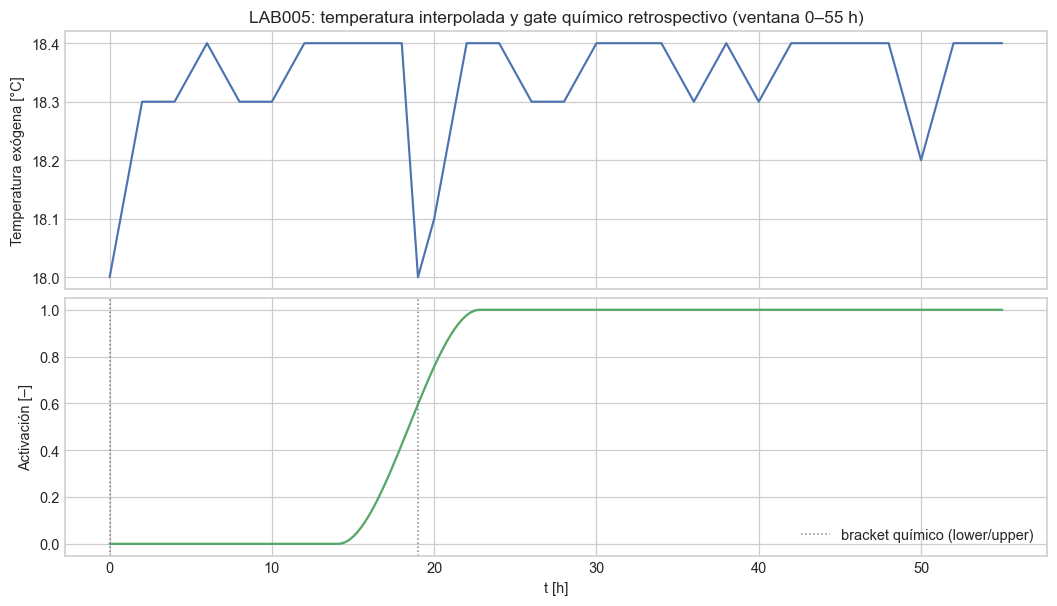

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 5.4), sharex=True, layout="constrained")
ax1.plot(tiempo_w, cache.temperature_used_c[ventana], color="#4c72b0", lw=1.4)
ax1.set_ylabel("Temperatura exógena [°C]")
ax1.set_title("LAB005: temperatura interpolada y gate químico retrospectivo (ventana 0–55 h)")

activacion_ref = co2_cross._bounded_smoothstep_activation(
    cache.time_h,
    cache.chemical_activity_lower_h,
    cache.chemical_activity_upper_h,
    parametros_co2["chem_activation_start_fraction"],
    parametros_co2["chem_activation_duration_fraction"],
)
ax2.plot(tiempo_w, activacion_ref[ventana], color="#55a868", lw=1.5)
ax2.axvline(cache.chemical_activity_lower_h, color="grey", ls=":", lw=1.0, label="bracket químico (lower/upper)")
ax2.axvline(cache.chemical_activity_upper_h, color="grey", ls=":", lw=1.0)
ax2.set_ylabel("Activación [–]")
ax2.set_xlabel("t [h]")
ax2.legend(loc="lower right")
plt.show()

## 3. Referencia de M0 con las funciones originales

La referencia se genera con el camino productivo vigente: `build_driver_cache` (que integra el núcleo con
`base.simulate` y calcula qprod biológico, saturaciones y bracket) y `raw_qgas_grid_prediction` con los flags
congelados de M0_actual. El pool disuelto de la referencia se reconstruye con la misma recursión interna de
`raw_qgas_grid_prediction` (la función no lo devuelve) y se comprueba que reproduce exactamente el `qgas` devuelto.

Dentro de la ventana el pulso todavía no ocurre, de modo que la trayectoria real y el contrafactual sin pulso que
usa M0 coinciden punto a punto.

In [6]:
qgas_ref, qprod_ref, o2_ref, phi_ref = co2_cross.raw_qgas_grid_prediction(cache, **M0_PREDICT_KW)
qobs_ref = parametros_co2["matrix_gain"] * qgas_ref


def pool_referencia(cache, qprod, qgas, sat_scale, k_release):
    """Replica la recursión del pool de raw_qgas_grid_prediction (liberación continua)."""
    t = cache.time_h
    csat = sat_scale * cache.csat_base_g_l
    cd = np.zeros(len(t), dtype=float)
    disuelto = 0.0
    for i in range(1, len(t)):
        dt = max(float(t[i] - t[i - 1]), 1e-9)
        disponible = disuelto / dt + max(float(qprod[i - 1]), 0.0)
        fraccion = disuelto / max(disuelto + float(csat[i]), 1e-12)
        liberacion = co2_cross.CO2_CONTINUOUS_RELEASE_FLOOR + (
            1.0 - co2_cross.CO2_CONTINUOUS_RELEASE_FLOOR
        ) * fraccion
        potencial = max(float(k_release), 1e-9) * disuelto * liberacion
        salido = min(potencial, disponible)
        assert abs(salido - float(qgas[i])) <= 1e-12
        disuelto = max(disuelto + dt * (max(float(qprod[i - 1]), 0.0) - salido), 0.0)
        cd[i] = disuelto
    return cd


cd_ref = pool_referencia(
    cache, qprod_ref, qgas_ref, parametros_co2["CO2sat_scale"], parametros_co2["kCO2_release_h"]
)

# En la ventana, trayectoria real y contrafactual sin pulso coinciden (el pulso es a las 55.0866 h).
assert cache.n_pulse_time_h > WINDOW_END_H
assert np.array_equal(cache.biomass_g_l[ventana], cache.biomass_no_n_pulse_g_l[ventana])
assert np.array_equal(cache.base_qprod_g_l_h[ventana], cache.base_qprod_no_n_pulse_g_l_h[ventana])

bio_ref_w = core_ref.loc[tiempo_w, list(BIO_STATES)].to_numpy(dtype=float)
print(f"referencia lista: {int(ventana.sum()) - 1} pasos internos de {GRID_H} h dentro de la ventana")

referencia lista: 220 pasos internos de 0.25 h dentro de la ventana


## 4. Adaptador de avance por intervalos

**Estado extendido** que viaja entre intervalos: los siete estados biológicos (`X, Xd, N, G, F, E, Gly`), el O₂ de la
capa M0 [mg/L], el pool de CO₂ disuelto [g/L] y el tiempo actual. La temperatura es una **entrada exógena**
(interpolación lineal de la serie del lote, igual que `base.temperature_at`); el gate es una función congelada del
tiempo absoluto.

**No se reescribe la cinética.** La producción biológica sale de `base.kinetic_terms` (mismo cálculo que
`_core_rates` → `CO2_G_PER_G_ETHANOL·(β_G+β_F)·X`), la integración usa `base.rhs` con LSODA y exactamente los mismos
`rtol/atol/max_step` de `base.simulate`, y las saturaciones usan las fórmulas de `co2_model`
(`o2_saturation_mg_l`, `co2_saturation_g_l`).

**Orden temporal por paso interno** (idéntico a `effective_qprod_grid` + `raw_qgas_grid_prediction`):

1. producción biológica y consumo de O₂ **al inicio del paso**, desde los estados actuales;
2. fracción anaeróbica φ_ana y contribución respiratoria con el O₂ del inicio del paso;
3. activación (gate congelado) y producción efectiva;
4. actualización explícita del O₂;
5. integración biológica LSODA del paso;
6. `csat` del **extremo siguiente** (temperatura y estados E, G, F de ese extremo);
7. liberación `qgas = min(potencial, disponible)` y actualización del pool con los límites `max(·, 0)` de M0.

**Convención temporal de los observables devueltos:**

| elemento | instante que representa |
|---|---|
| `qprod_bio`, `uptake`, `phi_ana`, `activation`, `qprod_eff` | inicio del paso (`t_start`) |
| `csat_end` | extremo siguiente (`t_end`) |
| `qgas`, `qobs` | intervalo `(t_start, t_end]`, asignado al extremo derecho |
| estados biológicos, `o2`, `cd` | extremo del paso (`t_end`); `*_start` al inicio |

`qobs = matrix_gain · qgas` es la escala empírica de observación; el flujo físico del balance es `qgas`.

In [7]:
@dataclass(frozen=True)
class M0Entradas:
    """Entradas exógenas del avance de M0.

    temperatura_batch porta únicamente la serie exógena de temperatura (misma
    interpolación lineal que base.temperature_at sobre el lote histórico, sin
    pulsos ni observaciones). activacion es el gate químico retrospectivo
    congelado, función solo del tiempo absoluto.
    """

    temperatura_batch: base.BatchData
    activacion: object  # callable[[float], float]
    paso_interno_h: float = co2_cross.DRIVER_GRID_H

    def temperatura_c(self, t):
        return base.temperature_at(self.temperatura_batch, float(t))


@dataclass
class M0Estado:
    """Estado extendido que viaja entre intervalos.

    biology lleva los siete estados biológicos en el orden de base.STATE_NAMES,
    o2_mg_l el O2 de la capa M0 y cd_g_l el pool de CO2 disuelto.
    """

    t_h: float
    biology: np.ndarray
    o2_mg_l: float
    cd_g_l: float

    def copy(self):
        return M0Estado(float(self.t_h), self.biology.copy(), float(self.o2_mg_l), float(self.cd_g_l))


def estado_inicial_m0(iniciales, entradas, parametros_co2):
    """Estado extendido en t = 0 según las convenciones de M0.

    El pool de CO2 disuelto parte vacío; el O2 parte de la saturación inicial
    escalada por O2_initial_scale, igual que effective_qprod_grid.
    """
    bio = np.array([float(iniciales[nombre]) for nombre in BIO_STATES], dtype=float)
    sat0 = co2_model.o2_saturation_mg_l(
        entradas.temperatura_c(0.0),
        float(bio[IDX["E"]]), float(bio[IDX["G"]]), float(bio[IDX["F"]]), 1.0,
    )
    o2_0 = max(float(parametros_co2["O2_initial_scale"]), 0.0) * float(sat0)
    return M0Estado(0.0, bio, o2_0, 0.0)


def advance_m0(estado_actual, tiempo_objetivo, entradas, theta, parametros_co2):
    """Avanza M0 desde estado_actual hasta tiempo_objetivo y devuelve (estado_siguiente, observables).

    Recorre pasos internos de entradas.paso_interno_h replicando la
    discretización de effective_qprod_grid y raw_qgas_grid_prediction con el
    orden temporal documentado arriba. tiempo_objetivo puede agrupar varios
    pasos internos (intervalo externo) sin cambiar la discretización.
    """
    destino = float(tiempo_objetivo)
    if destino < float(estado_actual.t_h) - 1e-9:
        raise ValueError("tiempo_objetivo es anterior al tiempo del estado")
    qmax = max(float(parametros_co2["O2_qmax_mg_gdw_h"]), 1e-12)
    k_release = max(float(parametros_co2["kCO2_release_h"]), 1e-9)
    sat_scale = float(parametros_co2["CO2sat_scale"])
    matrix_gain = float(parametros_co2["matrix_gain"])

    filas = []
    estado = estado_actual.copy()
    while float(estado.t_h) < destino - 1e-9:
        t0 = float(estado.t_h)
        t1 = min(t0 + float(entradas.paso_interno_h), destino)
        dt = max(t1 - t0, 1e-9)
        bio = estado.biology
        x, n, g, f, e = (float(bio[IDX[k]]) for k in ("X", "N", "G", "F", "E"))

        # 1) producción biológica y consumo de O2 al inicio del paso
        terms = base.kinetic_terms(theta, entradas.temperatura_c(t0), x, n, g, f, e)
        qprod_bio = joint.CO2_G_PER_G_ETHANOL * max((terms["beta_g"] + terms["beta_f"]) * x, 0.0)
        o2 = max(float(estado.o2_mg_l), 0.0)
        uptake = qmax * max(x, 0.0) * o2 / (co2_cross.O2_K_MG_L + o2)

        # 2) fracción anaeróbica y contribución respiratoria
        phi_ana = (co2_cross.O2_ANA_K_MG_L ** co2_cross.O2_ANA_HILL) / (
            co2_cross.O2_ANA_K_MG_L ** co2_cross.O2_ANA_HILL + o2 ** co2_cross.O2_ANA_HILL
        )
        ferment = co2_cross.O2_CRABTREE_FLOOR + (1.0 - co2_cross.O2_CRABTREE_FLOOR) * phi_ana
        respiratorio = co2_model.CO2_G_PER_MG_O2_RESP * max(uptake, 0.0)

        # 3) gate congelado y producción efectiva
        activacion = float(entradas.activacion(t0))
        qprod_efectiva = max(activacion * (qprod_bio * ferment + respiratorio), 0.0)

        # 4) actualización explícita del O2
        o2_siguiente = max(o2 - dt * uptake, 0.0)

        # 5) integración biológica, idéntica a base.simulate entre puntos de salida
        sol = solve_ivp(
            lambda t, y: base.rhs(t, y, theta, entradas.temperatura_batch),
            (t0, t1), bio, t_eval=[t1],
            method="LSODA", rtol=1e-6, atol=1e-8, max_step=2.0,
        )
        if not sol.success or sol.y.shape[1] != 1:
            raise RuntimeError(f"LSODA falló en [{t0}, {t1}]")
        bio_siguiente = np.asarray(sol.y[:, -1], dtype=float)
        bio_reportada = np.clip(
            bio_siguiente,
            [base.STATE_BOUNDS[s][0] for s in BIO_STATES],
            [base.STATE_BOUNDS[s][1] for s in BIO_STATES],
        )

        # 6) csat del extremo siguiente con los estados de ese extremo
        csat = co2_model.co2_saturation_g_l(
            entradas.temperatura_c(t1),
            float(bio_siguiente[IDX["E"]]), float(bio_siguiente[IDX["G"]]), float(bio_siguiente[IDX["F"]]),
            sat_scale,
        )

        # 7) liberación y actualización del pool (límites y convenciones de M0)
        cd = max(float(estado.cd_g_l), 0.0)
        disponible = cd / dt + qprod_efectiva
        fraccion_disuelto = cd / max(cd + csat, 1e-12)
        fraccion_liberacion = co2_cross.CO2_CONTINUOUS_RELEASE_FLOOR + (
            1.0 - co2_cross.CO2_CONTINUOUS_RELEASE_FLOOR
        ) * fraccion_disuelto
        potencial = k_release * cd * fraccion_liberacion
        qgas = min(potencial, disponible)
        cd_siguiente = max(cd + dt * (qprod_efectiva - qgas), 0.0)

        filas.append({
            "t_start_h": t0, "t_end_h": t1, "dt_h": dt,
            "qprod_bio_g_l_h": qprod_bio, "qprod_eff_g_l_h": qprod_efectiva,
            "uptake_mg_l_h": uptake, "phi_ana": phi_ana, "activation": activacion,
            "o2_start_mg_l": o2, "o2_end_mg_l": o2_siguiente,
            "csat_end_g_l": csat,
            "cd_start_g_l": cd, "cd_end_g_l": cd_siguiente,
            "qgas_g_l_h": qgas, "qobs_g_l_h": matrix_gain * qgas,
            **{f"{s}_end": float(bio_reportada[i]) for s, i in IDX.items()},
        })
        estado = M0Estado(t1, bio_siguiente, o2_siguiente, cd_siguiente)
    return estado, pd.DataFrame(filas)


def recorrer_por_intervalos(estado_inicial, bordes_h, entradas, theta, parametros_co2, correccion=None):
    """Avanza de borde externo en borde externo.

    correccion(estado) -> estado se aplica al llegar a cada borde, después del
    avance; permite inyectar correcciones puntuales (como la de la §6).
    """
    estados = [estado_inicial.copy()]
    partes = []
    estado = estado_inicial.copy()
    for destino in bordes_h:
        estado, tramo = advance_m0(estado, float(destino), entradas, theta, parametros_co2)
        if correccion is not None:
            estado = correccion(estado)
        estados.append(estado.copy())
        partes.append(tramo)
    return estados, pd.concat(partes, ignore_index=True)


entradas = M0Entradas(
    temperatura_batch=base.BatchData(
        medium=lote_lab005.medium,
        batch=lote_lab005.batch,
        time=lote_lab005.time.copy(),
        temperature_c=lote_lab005.temperature_c.copy(),
        pulses={canal: tuple() for canal in base.INPUT_CHANNELS},
        observations={s: np.full(len(lote_lab005.time), np.nan) for s in BIO_STATES},
        initials={s: float(lote_lab005.initials[s]) for s in BIO_STATES},
    ),
    activacion=lambda t: float(co2_cross._bounded_smoothstep_activation(
        np.asarray([float(t)]),
        cache.chemical_activity_lower_h,
        cache.chemical_activity_upper_h,
        parametros_co2["chem_activation_start_fraction"],
        parametros_co2["chem_activation_duration_fraction"],
    )[0]),
)
# La temperatura exógena del adaptador es idéntica a la usada por el cache.
assert all(
    entradas.temperatura_c(float(t)) == float(cache.temperature_used_c[i])
    for i, t in enumerate(cache.time_h)
)

estado0 = estado_inicial_m0(lote_lab005.initials, entradas, parametros_co2)
assert np.isclose(
    estado0.o2_mg_l,
    parametros_co2["O2_initial_scale"] * cache.o2_saturation_base_mg_l[0],
    rtol=1e-12,
)
print(f"O2 inicial del adaptador: {estado0.o2_mg_l:.6f} mg/L | pool inicial: {estado0.cd_g_l} g/L")

O2 inicial del adaptador: 1.346538 mg/L | pool inicial: 0.0 g/L


## 5. Comprobación 1: referencia frente a avance por intervalos

El adaptador recorre la ventana con **intervalos externos de 1 h** (4 pasos internos de 0.25 h cada uno). Se comparan
contra la referencia: los siete estados biológicos, la producción efectiva, el O₂, el pool disuelto, `qgas` y `qobs`.

Las tolerancias se justifican así: la secuencia de llamadas a LSODA del adaptador es idéntica a la de
`base.simulate` (mismos intervalos, mismas condiciones iniciales), por lo que la diferencia esperable es solo ruido
de almacenamiento flotante; se exige estar por debajo de la escala de las toleraciones de integración (`atol` 1e-8
para estados) y por debajo del redondeo flotante en las recurrencias explícitas de la capa CO₂ (1e-12).

In [8]:
bordes_1h = np.arange(1.0, WINDOW_END_H + 1e-9, 1.0)
estados_nom, corrida_nom = recorrer_por_intervalos(estado0, bordes_1h, entradas, theta_full, parametros_co2)
assert estados_nom[-1].t_h == WINDOW_END_H
assert np.allclose(corrida_nom["t_end_h"].to_numpy(float), tiempo_w[1:], rtol=0.0, atol=0.0)


def fila_error(serie, ref, ada, unidad, tol, justificacion):
    ref = np.asarray(ref, dtype=float)
    ada = np.asarray(ada, dtype=float)
    err = float(np.max(np.abs(ref - ada)))
    return {
        "serie": serie,
        "unidad": unidad,
        "err_abs_max": err,
        "err_rel_max": err / max(float(np.max(np.abs(ref))), 1e-300),
        "tolerancia": tol,
        "justificacion": justificacion,
        "veredicto": "PASS" if err <= tol else "FAIL",
    }


filas_error = [
    *(
        fila_error(
            s, bio_ref_w[1:, j], corrida_nom[f"{s}_end"].to_numpy(float), UNIDADES[s],
            1e-8, "atol de LSODA de base.simulate; secuencia de llamadas al solver idéntica",
        )
        for j, s in enumerate(BIO_STATES)
    ),
    fila_error("qprod_efectiva", qprod_ref[ventana][:-1], corrida_nom["qprod_eff_g_l_h"],
               "g/L/h", 1e-10, "términos algebraicos sobre estados idénticos"),
    fila_error("O2", o2_ref[ventana][1:], corrida_nom["o2_end_mg_l"],
               "mg/L", 1e-12, "recurrencia explícita idéntica"),
    fila_error("CO2 disuelto (pool)", cd_ref[ventana][1:], corrida_nom["cd_end_g_l"],
               "g/L", 1e-12, "recurrencia del pool idéntica"),
    fila_error("qgas", qgas_ref[ventana][1:], corrida_nom["qgas_g_l_h"],
               "g/L/h", 1e-12, "mismo potencial de liberación y misma disponibilidad"),
    fila_error("qobs", qobs_ref[ventana][1:], corrida_nom["qobs_g_l_h"],
               "g/L/h", 2e-12, "matrix_gain · qgas con qgas idéntico"),
]
tabla_errores = pd.DataFrame(filas_error)
display(tabla_errores)
assert (tabla_errores["veredicto"] == "PASS").all()

,serie,unidad,err_abs_max,err_rel_max,tolerancia,justificacion,veredicto
0,X,kg/m3,0,0,1e-08,atol de LSODA de base.simulate; secuencia de l...,PASS
1,Xd,kg/m3,0,0,1e-08,atol de LSODA de base.simulate; secuencia de l...,PASS
2,N,kg/m3,0,0,1e-08,atol de LSODA de base.simulate; secuencia de l...,PASS
3,G,g/L,0,0,1e-08,atol de LSODA de base.simulate; secuencia de l...,PASS
4,F,g/L,0,0,1e-08,atol de LSODA de base.simulate; secuencia de l...,PASS
5,E,g/L,0,0,1e-08,atol de LSODA de base.simulate; secuencia de l...,PASS
6,Gly,g/L,0,0,1e-08,atol de LSODA de base.simulate; secuencia de l...,PASS
7,qprod_efectiva,g/L/h,0,0,1e-10,términos algebraicos sobre estados idénticos,PASS
8,O2,mg/L,0,0,1e-12,recurrencia explícita idéntica,PASS
9,CO2 disuelto (pool),g/L,4.44089e-16,1.78612e-16,1e-12,recurrencia del pool idéntica,PASS


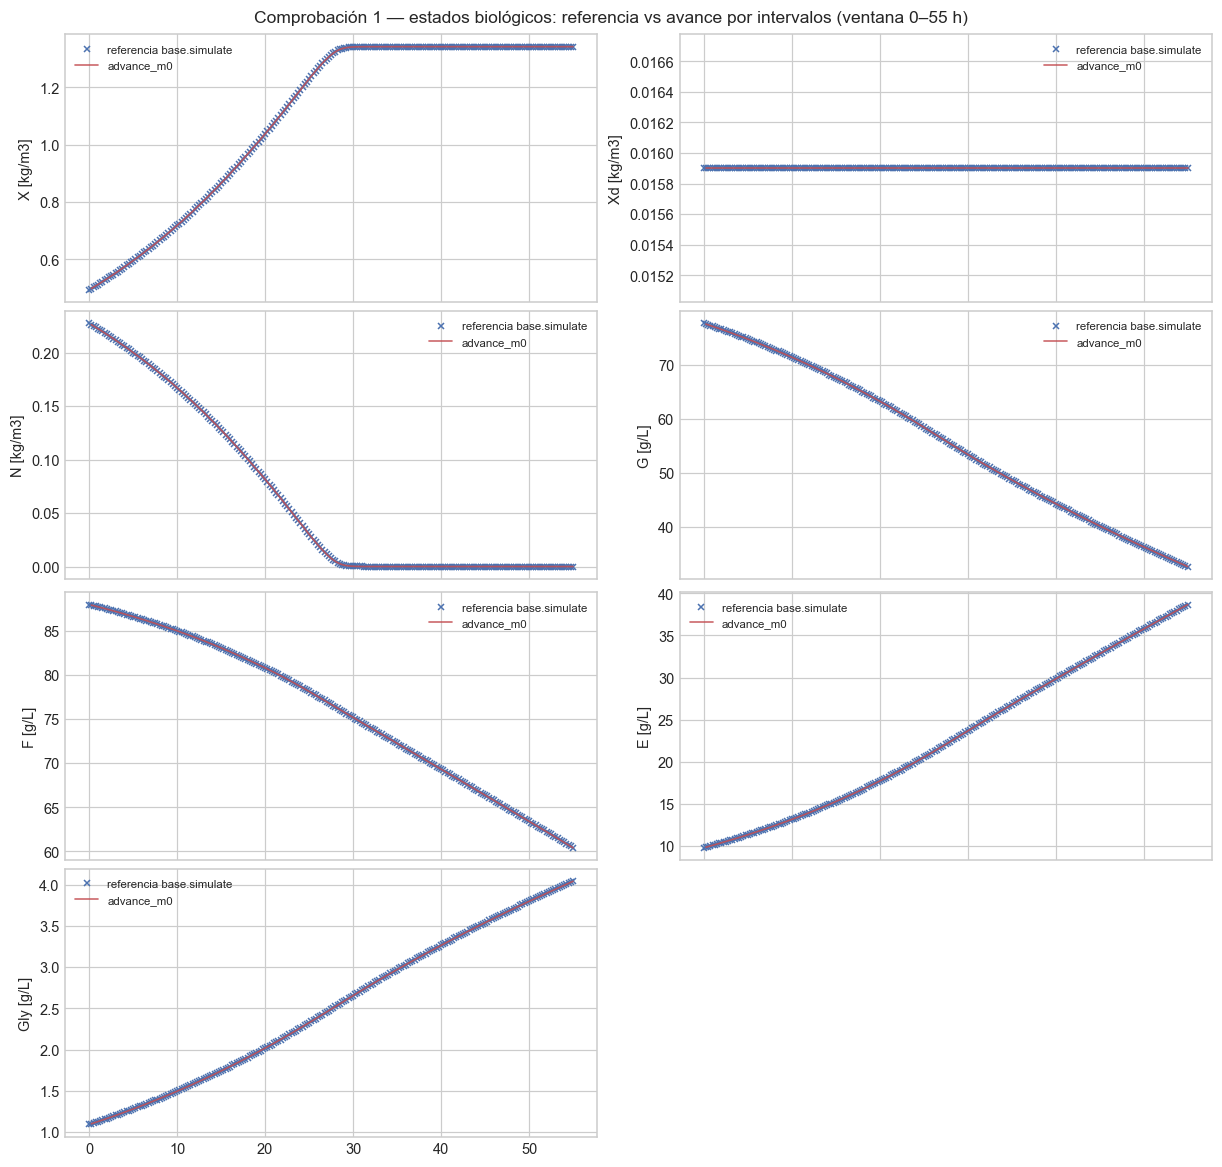

In [9]:
fig, ejes = plt.subplots(4, 2, figsize=(11.0, 10.5), sharex=True, layout="constrained")
for ax, s in zip(ejes.flat, BIO_STATES):
    ax.plot(tiempo_w, bio_ref_w[:, IDX[s]], "x", ms=3.5, color="#4c72b0", label="referencia base.simulate")
    ax.plot(tiempo_w[1:], corrida_nom[f"{s}_end"], "-", lw=1.1, color="#c44e52", alpha=0.85, label="advance_m0")
    ax.set_ylabel(f"{s} [{UNIDADES[s]}]")
    ax.legend(loc="best", fontsize=7.5)
ejes[-1, -1].axis("off")
fig.suptitle("Comprobación 1 — estados biológicos: referencia vs avance por intervalos (ventana 0–55 h)")
plt.show()

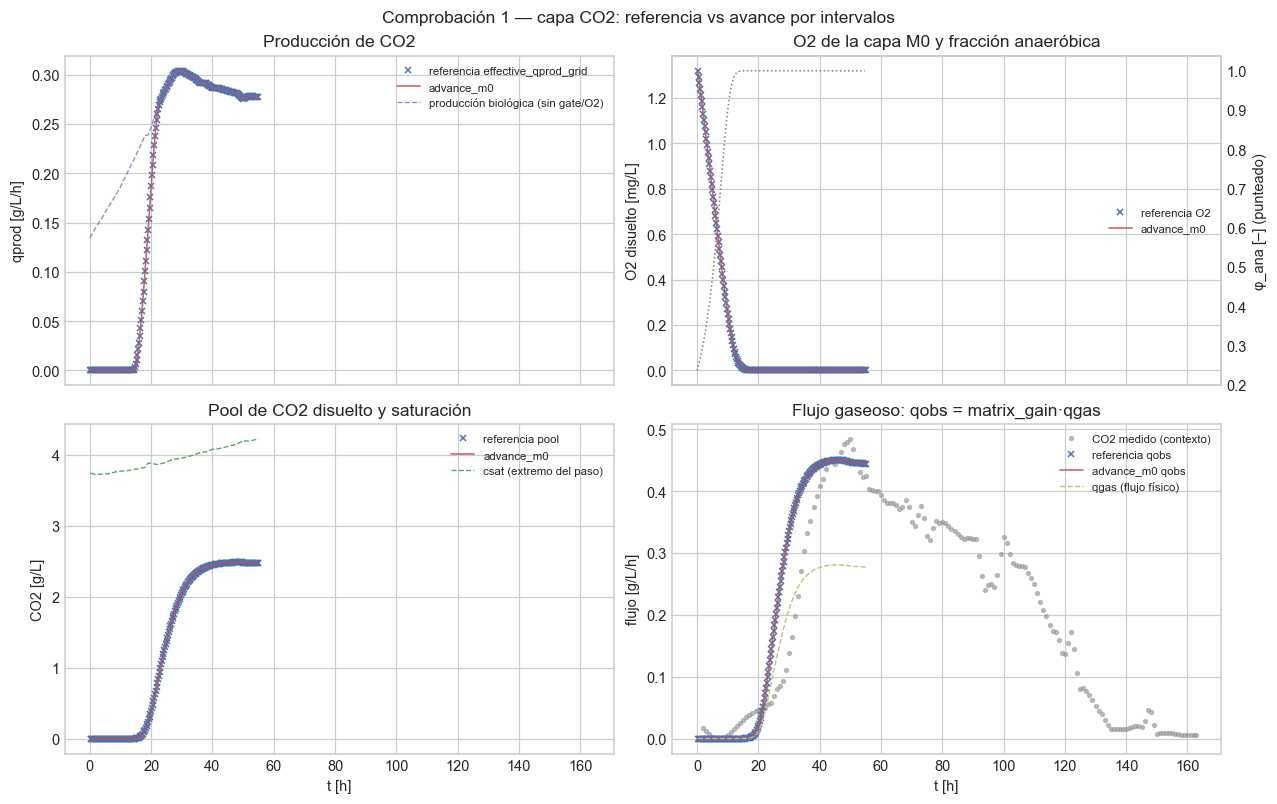

In [10]:
fig, ejes = plt.subplots(2, 2, figsize=(11.5, 7.2), sharex=True, layout="constrained")

ax = ejes[0, 0]
ax.plot(tiempo_w[:-1], qprod_ref[ventana][:-1], "x", ms=3.5, color="#4c72b0", label="referencia effective_qprod_grid")
ax.plot(corrida_nom["t_start_h"], corrida_nom["qprod_eff_g_l_h"], "-", lw=1.1, color="#c44e52", alpha=0.85, label="advance_m0")
ax.plot(corrida_nom["t_start_h"], corrida_nom["qprod_bio_g_l_h"], "--", lw=0.9, color="#8172b2", alpha=0.8, label="producción biológica (sin gate/O2)")
ax.set_ylabel("qprod [g/L/h]")
ax.set_title("Producción de CO2")
ax.legend(fontsize=7.5)

ax = ejes[0, 1]
ax.plot(tiempo_w[1:], o2_ref[ventana][1:], "x", ms=3.5, color="#4c72b0", label="referencia O2")
ax.plot(corrida_nom["t_end_h"], corrida_nom["o2_end_mg_l"], "-", lw=1.1, color="#c44e52", alpha=0.85, label="advance_m0")
ax.set_ylabel("O2 disuelto [mg/L]")
axt = ax.twinx()
axt.plot(corrida_nom["t_start_h"], corrida_nom["phi_ana"], ":", lw=1.0, color="#937860")
axt.set_ylabel("φ_ana [–] (punteado)")
axt.grid(False)
ax.set_title("O2 de la capa M0 y fracción anaeróbica")
ax.legend(fontsize=7.5, loc="center right")

ax = ejes[1, 0]
ax.plot(tiempo_w[1:], cd_ref[ventana][1:], "x", ms=3.5, color="#4c72b0", label="referencia pool")
ax.plot(corrida_nom["t_end_h"], corrida_nom["cd_end_g_l"], "-", lw=1.1, color="#c44e52", alpha=0.85, label="advance_m0")
ax.plot(corrida_nom["t_end_h"], corrida_nom["csat_end_g_l"], "--", lw=0.9, color="#55a868", label="csat (extremo del paso)")
ax.set_ylabel("CO2 [g/L]")
ax.set_xlabel("t [h]")
ax.set_title("Pool de CO2 disuelto y saturación")
ax.legend(fontsize=7.5)

ax = ejes[1, 1]
grupo = obs_lab005.dropna(subset=["co2_rate_g_l_h"])
ax.plot(grupo["t_h"], grupo["co2_rate_g_l_h"], "o", ms=2.5, color="#999999", alpha=0.6, label="CO2 medido (contexto)")
ax.plot(tiempo_w[1:], qobs_ref[ventana][1:], "x", ms=3.5, color="#4c72b0", label="referencia qobs")
ax.plot(corrida_nom["t_end_h"], corrida_nom["qobs_g_l_h"], "-", lw=1.1, color="#c44e52", alpha=0.85, label="advance_m0 qobs")
ax.plot(corrida_nom["t_end_h"], corrida_nom["qgas_g_l_h"], "--", lw=0.9, color="#ccb974", label="qgas (flujo físico)")
ax.set_ylabel("flujo [g/L/h]")
ax.set_xlabel("t [h]")
ax.set_title("Flujo gaseoso: qobs = matrix_gain·qgas")
ax.legend(fontsize=7.5)

fig.suptitle("Comprobación 1 — capa CO2: referencia vs avance por intervalos")
plt.show()

In [11]:
# --- Intervalos externos de 2 h: misma discretización interna -----------------
bordes_2h = np.append(np.arange(2.0, WINDOW_END_H, 2.0), WINDOW_END_H)  # último tramo externo: 54->55 h
estados_2h, corrida_2h = recorrer_por_intervalos(estado0, bordes_2h, entradas, theta_full, parametros_co2)
agrupacion_2h_ok = corrida_nom.equals(corrida_2h)
final_2h_ok = (
    np.array_equal(estados_nom[-1].biology, estados_2h[-1].biology)
    and estados_nom[-1].o2_mg_l == estados_2h[-1].o2_mg_l
    and estados_nom[-1].cd_g_l == estados_2h[-1].cd_g_l
)

# --- Checkpoint en 20 h y reanudación ----------------------------------------
estado_ck = estados_nom[20].copy()
assert estado_ck.t_h == CORRECTION_TIME_H
fin_20 = corrida_nom[corrida_nom["t_end_h"].eq(CORRECTION_TIME_H)].iloc[0]
memoria_ok = bool(
    estado_ck.o2_mg_l == float(fin_20["o2_end_mg_l"]) and estado_ck.cd_g_l == float(fin_20["cd_end_g_l"])
)
estado_fin_ck, tramo_ck = advance_m0(estado_ck, WINDOW_END_H, entradas, theta_full, parametros_co2)
tramo_nom_post = corrida_nom[corrida_nom["t_start_h"] >= CORRECTION_TIME_H - 1e-9].reset_index(drop=True)
reanudacion_ok = bool(tramo_ck.equals(tramo_nom_post))
estado_final_ok = (
    np.array_equal(estado_fin_ck.biology, estados_nom[-1].biology)
    and estado_fin_ck.o2_mg_l == estados_nom[-1].o2_mg_l
    and estado_fin_ck.cd_g_l == estados_nom[-1].cd_g_l
)

display(pd.DataFrame([
    {"comprobación": "Intervalos externos de 2 h idénticos a 1 h (misma discretización interna)", "resultado": agrupacion_2h_ok},
    {"comprobación": "Estado final idéntico con bordes de 2 h", "resultado": final_2h_ok},
    {"comprobación": "O2 y pool viajan en el estado del checkpoint (no se reinicializan)", "resultado": memoria_ok},
    {"comprobación": "Reanudar desde checkpoint 20 h reproduce la trayectoria posterior bit a bit", "resultado": reanudacion_ok},
    {"comprobación": "Estado final idéntico tras la reanudación", "resultado": estado_final_ok},
]))
assert agrupacion_2h_ok and final_2h_ok and memoria_ok and reanudacion_ok and estado_final_ok

,comprobación,resultado
0,Intervalos externos de 2 h idénticos a 1 h (mi...,True
1,Estado final idéntico con bordes de 2 h,True
2,O2 y pool viajan en el estado del checkpoint (...,True
3,Reanudar desde checkpoint 20 h reproduce la tr...,True
4,Estado final idéntico tras la reanudación,True


## 6. Comprobación 2: corrección artificial de biomasa

En el borde externo de las **20 h** se aumenta X un 10 %, una sola vez, manteniendo los demás seis estados y **sin
reinicializar O₂ ni el pool de CO₂ disuelto**. A partir de ahí el adaptador recalcula las tasas desde los estados
corregidos: no existe ninguna trayectoria nominal precalculada de X o qprod alimentando el recorrido corregido.

Esta corrección es una **prueba técnica** de propagación, no una corrección calculada por un EKF. El gate sigue
congelado, igual que en la corrida nominal.

In [12]:
def corregir_x(estado):
    if abs(estado.t_h - CORRECTION_TIME_H) > 1e-9:
        return estado
    corregido = estado.copy()
    corregido.biology[IDX["X"]] *= CORRECTION_X_FACTOR
    return corregido


estados_cor, corrida_cor = recorrer_por_intervalos(
    estado0, bordes_1h, entradas, theta_full, parametros_co2, correccion=corregir_x
)

# --- Verificaciones -----------------------------------------------------------
pre_nom = corrida_nom[corrida_nom["t_end_h"] <= CORRECTION_TIME_H + 1e-9].reset_index(drop=True)
pre_cor = corrida_cor[corrida_cor["t_end_h"] <= CORRECTION_TIME_H + 1e-9].reset_index(drop=True)
previa_intacta = bool(pre_nom.equals(pre_cor))

x_antes = float(estados_nom[20].biology[IDX["X"]])
x_despues = float(estados_cor[20].biology[IDX["X"]])
salto_ok = bool(x_despues == x_antes * CORRECTION_X_FACTOR)
delta_otros = float(np.max(np.abs(estados_cor[20].biology[1:] - estados_nom[20].biology[1:])))
delta_o2 = abs(estados_cor[20].o2_mg_l - estados_nom[20].o2_mg_l)
delta_cd = abs(estados_cor[20].cd_g_l - estados_nom[20].cd_g_l)
pools_ok = bool(delta_o2 == 0.0 and delta_cd == 0.0)

q1_nom = float(corrida_nom.loc[corrida_nom["t_start_h"].eq(CORRECTION_TIME_H), "qprod_eff_g_l_h"].iloc[0])
q1_cor = float(corrida_cor.loc[corrida_cor["t_start_h"].eq(CORRECTION_TIME_H), "qprod_eff_g_l_h"].iloc[0])
ratio_q1 = q1_cor / q1_nom  # a O2 y gate del instante, las tasas son lineales en X

t_cor = corrida_cor["t_end_h"].to_numpy(float)
qobs_nom_v = corrida_nom["qobs_g_l_h"].to_numpy(float)
qobs_cor_v = corrida_cor["qobs_g_l_h"].to_numpy(float)
desviacion = np.abs(qobs_cor_v - qobs_nom_v) / np.maximum(np.abs(qobs_nom_v), 1e-12)
post = t_cor > CORRECTION_TIME_H + 1e-9
idx5 = np.flatnonzero(post & (desviacion > 0.05))
t_respuesta_5pct = float(t_cor[idx5[0]]) if len(idx5) else float("nan")
delta_qobs_final = float(qobs_cor_v[-1] - qobs_nom_v[-1])

tabla_correccion = pd.DataFrame([
    {"comprobación": "Trayectoria anterior a las 20 h intacta (bit a bit)", "valor": previa_intacta},
    {"comprobación": f"X(20 h) = {x_antes:.6f} → {x_despues:.6f} kg/m3 (×1.10 exacto)", "valor": salto_ok},
    {"comprobación": "Demás estados biológicos sin cambio, max |Δ|", "valor": delta_otros},
    {"comprobación": "O2(20 h) conservado, |Δ| [mg/L]", "valor": delta_o2},
    {"comprobación": "Pool Cd(20 h) conservado, |Δ| [g/L]", "valor": delta_cd},
    {"comprobación": "qprod efectivo del primer paso posterior / nominal (esperado 1.10)", "valor": ratio_q1},
    {"comprobación": "Primer instante con |Δqobs| > 5 % del nominal [h]", "valor": t_respuesta_5pct},
    {"comprobación": "Δqobs al final de la ventana [g/L/h]", "valor": delta_qobs_final},
])
display(tabla_correccion)
assert previa_intacta and salto_ok and delta_otros == 0.0 and pools_ok
assert np.isclose(ratio_q1, CORRECTION_X_FACTOR, rtol=1e-12)
assert np.isfinite(t_respuesta_5pct)

,comprobación,valor
0,Trayectoria anterior a las 20 h intacta (bit a...,True
1,X(20 h) = 1.037500 → 1.141250 kg/m3 (×1.10 exa...,True
2,"Demás estados biológicos sin cambio, max |Δ|",0
3,"O2(20 h) conservado, |Δ| [mg/L]",0
4,"Pool Cd(20 h) conservado, |Δ| [g/L]",0
5,qprod efectivo del primer paso posterior / nom...,1.1
6,Primer instante con |Δqobs| > 5 % del nominal [h],21.25
7,Δqobs al final de la ventana [g/L/h],0.0319291


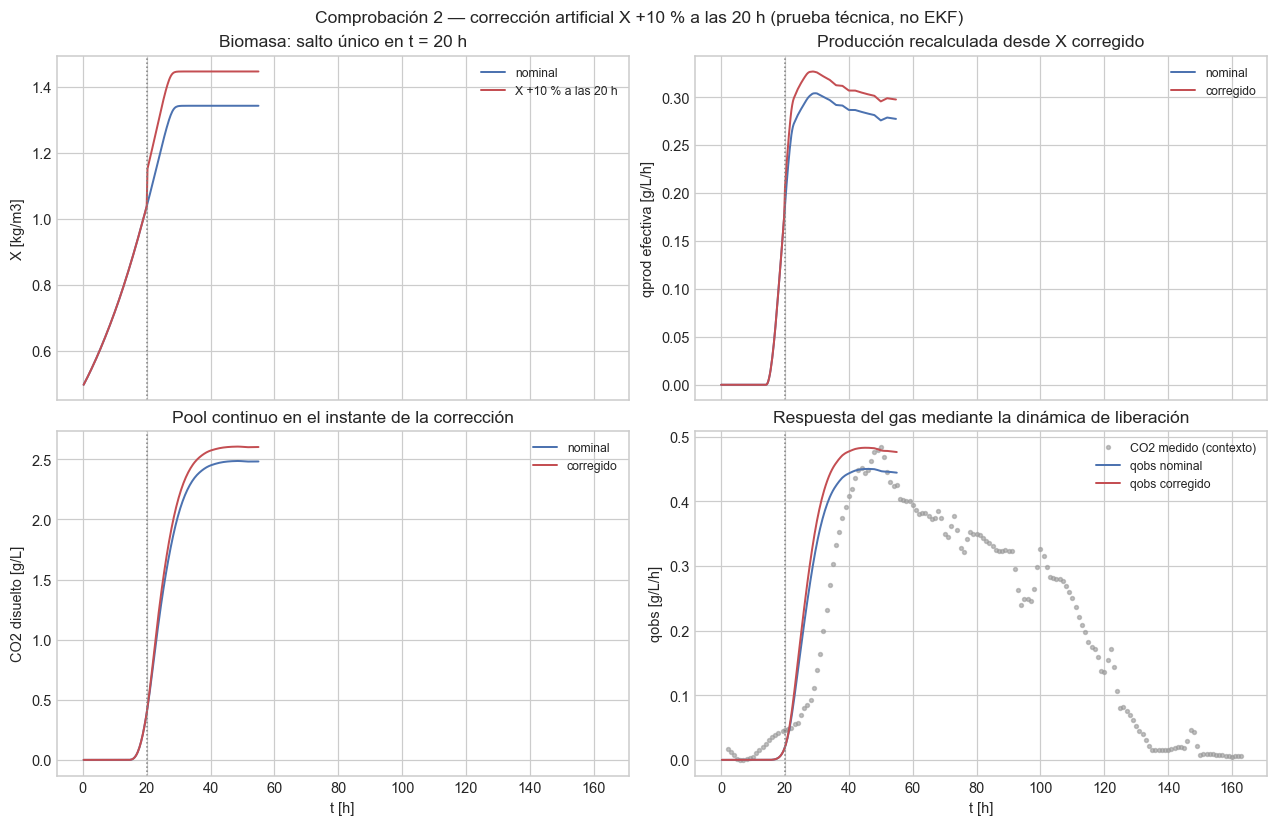

In [13]:
fig, ejes = plt.subplots(2, 2, figsize=(11.5, 7.4), sharex=True, layout="constrained")

ax = ejes[0, 0]
ax.plot(corrida_nom["t_end_h"], corrida_nom["X_end"], "-", lw=1.3, color="#4c72b0", label="nominal")
ax.plot(corrida_cor["t_end_h"], corrida_cor["X_end"], "-", lw=1.3, color="#c44e52", label="X +10 % a las 20 h")
ax.axvline(CORRECTION_TIME_H, color="grey", ls=":", lw=1.0)
ax.set_ylabel("X [kg/m3]")
ax.set_title("Biomasa: salto único en t = 20 h")
ax.legend(fontsize=8)

ax = ejes[0, 1]
ax.plot(corrida_nom["t_start_h"], corrida_nom["qprod_eff_g_l_h"], "-", lw=1.3, color="#4c72b0", label="nominal")
ax.plot(corrida_cor["t_start_h"], corrida_cor["qprod_eff_g_l_h"], "-", lw=1.3, color="#c44e52", label="corregido")
ax.axvline(CORRECTION_TIME_H, color="grey", ls=":", lw=1.0)
ax.set_ylabel("qprod efectiva [g/L/h]")
ax.set_title("Producción recalculada desde X corregido")
ax.legend(fontsize=8)

ax = ejes[1, 0]
ax.plot(corrida_nom["t_end_h"], corrida_nom["cd_end_g_l"], "-", lw=1.3, color="#4c72b0", label="nominal")
ax.plot(corrida_cor["t_end_h"], corrida_cor["cd_end_g_l"], "-", lw=1.3, color="#c44e52", label="corregido")
ax.axvline(CORRECTION_TIME_H, color="grey", ls=":", lw=1.0)
ax.set_ylabel("CO2 disuelto [g/L]")
ax.set_xlabel("t [h]")
ax.set_title("Pool continuo en el instante de la corrección")
ax.legend(fontsize=8)

ax = ejes[1, 1]
grupo = obs_lab005.dropna(subset=["co2_rate_g_l_h"])
ax.plot(grupo["t_h"], grupo["co2_rate_g_l_h"], "o", ms=2.5, color="#999999", alpha=0.6, label="CO2 medido (contexto)")
ax.plot(corrida_nom["t_end_h"], corrida_nom["qobs_g_l_h"], "-", lw=1.3, color="#4c72b0", label="qobs nominal")
ax.plot(corrida_cor["t_end_h"], corrida_cor["qobs_g_l_h"], "-", lw=1.3, color="#c44e52", label="qobs corregido")
ax.axvline(CORRECTION_TIME_H, color="grey", ls=":", lw=1.0)
ax.set_ylabel("qobs [g/L/h]")
ax.set_xlabel("t [h]")
ax.set_title("Respuesta del gas mediante la dinámica de liberación")
ax.legend(fontsize=8)

fig.suptitle("Comprobación 2 — corrección artificial X +10 % a las 20 h (prueba técnica, no EKF)")
plt.show()

## 7. Comprobación 3: balance discreto del pool de CO₂

Para cada paso interno de ambas corridas se verifica el balance discreto de M0

$$C_d^{sig} = C_d + \Delta t \left( qprod^{inicio} - qgas^{intervalo} \right)$$

junto con los límites y convenciones de M0: `qgas ≤ disponible` (pool/Δt + producción del inicio del paso),
no-negatividad de pool, producción y flujo. El balance usa **qgas**; `qobs` no es un flujo físico — `matrix_gain`
es solo una escala empírica de observación.

In [14]:
def auditoria_balance(corrida):
    cd0 = corrida["cd_start_g_l"].to_numpy(float)
    cd1 = corrida["cd_end_g_l"].to_numpy(float)
    dt = corrida["dt_h"].to_numpy(float)
    qp = corrida["qprod_eff_g_l_h"].to_numpy(float)
    qg = corrida["qgas_g_l_h"].to_numpy(float)
    residual = cd1 - (cd0 + dt * (qp - qg))
    return {
        "pasos": int(len(corrida)),
        "residual_balance_max_g_l": float(np.max(np.abs(residual))),
        "cd_min_g_l": float(cd1.min()),
        "max_qgas_menos_disponible_g_l_h": float(np.max(qg - (cd0 / dt + qp))),
        "qprod_min_g_l_h": float(qp.min()),
        "qgas_min_g_l_h": float(qg.min()),
    }


tabla_balance = pd.DataFrame([
    {"corrida": "nominal", **auditoria_balance(corrida_nom)},
    {"corrida": "X corregido +10 % a las 20 h", **auditoria_balance(corrida_cor)},
])
display(tabla_balance)
assert tabla_balance["residual_balance_max_g_l"].max() <= 1e-12
assert tabla_balance["cd_min_g_l"].min() >= 0.0
assert tabla_balance["max_qgas_menos_disponible_g_l_h"].max() <= 1e-15
assert tabla_balance["qprod_min_g_l_h"].min() >= 0.0
assert tabla_balance["qgas_min_g_l_h"].min() >= 0.0

,corrida,pasos,residual_balance_max_g_l,cd_min_g_l,max_qgas_menos_disponible_g_l_h,qprod_min_g_l_h,qgas_min_g_l_h
0,nominal,220,0,0,0,0,0
1,X corregido +10 % a las 20 h,220,0,0,0,0,0


## 8. Resumen y estado para el EKF

**Queda preparado para el EKF**

- `advance_m0(estado_actual, tiempo_objetivo, entradas, theta, parametros_co2)` con estado extendido
  (7 estados biológicos + O₂ + pool de CO₂ disuelto + tiempo) y temperatura exógena.
- Reproducción verificada de M0 (estados, producción, O₂, pool, qgas, qobs) y de su discretización interna de 0.25 h,
  agrupable en intervalos externos sin cambiar resultados.
- Reanudación desde checkpoints y propagación de correcciones de estado verificadas, incluida la conservación de la
  memoria de O₂/CO₂ disuelto y el recálculo de tasas desde el estado corregido.
- Balance discreto del pool auditado; convención temporal de cada observable documentada.

**Pendiente**

- Causalización del gate de activación (hoy usa un bracket construido con química posterior).
- Observabilidad del estado extendido frente a las mediciones disponibles.
- Matrices de incertidumbre P0/Q/R y el propio filtro.
- Tratamiento del período post-nutrición (M0 usa un contrafactual sin pulso para construir su transición).

In [15]:
err_bio = float(tabla_errores.loc[tabla_errores["serie"].isin(BIO_STATES), "err_abs_max"].max())
err_capa = float(tabla_errores.loc[~tabla_errores["serie"].isin(BIO_STATES), "err_abs_max"].max())
resumen_final = pd.DataFrame([
    {"comprobación": "advance_m0 reproduce los 7 estados biológicos de la referencia",
     "resultado": f"max |err| = {err_bio:.3e} (tol 1e-8)", "veredicto": "PASS" if err_bio <= 1e-8 else "FAIL"},
    {"comprobación": "advance_m0 reproduce producción efectiva, O2, pool, qgas y qobs",
     "resultado": f"max |err| = {err_capa:.3e} (tol 2e-12)", "veredicto": "PASS" if err_capa <= 2e-12 else "FAIL"},
    {"comprobación": "Bordes externos de 2 h no cambian la discretización interna",
     "resultado": str(agrupacion_2h_ok), "veredicto": "PASS" if agrupacion_2h_ok else "FAIL"},
    {"comprobación": "Reanudación desde checkpoint (20 h) bit a bit",
     "resultado": str(reanudacion_ok), "veredicto": "PASS" if reanudacion_ok else "FAIL"},
    {"comprobación": "Memoria de O2 y CO2 disuelto entre intervalos (sin reinicialización)",
     "resultado": str(memoria_ok), "veredicto": "PASS" if memoria_ok else "FAIL"},
    {"comprobación": "Corrección X+10 %: trayectoria previa intacta, salto exacto, demás estados sin cambio",
     "resultado": str(previa_intacta and salto_ok and delta_otros == 0.0),
     "veredicto": "PASS" if (previa_intacta and salto_ok and delta_otros == 0.0) else "FAIL"},
    {"comprobación": "Pools de O2/CO2 disuelto conservados en el instante de la corrección",
     "resultado": str(pools_ok), "veredicto": "PASS" if pools_ok else "FAIL"},
    {"comprobación": "Producción recalculada desde X corregido (primer paso posterior)",
     "resultado": f"ratio = {ratio_q1:.10f} (esperado 1.10)",
     "veredicto": "PASS" if np.isclose(ratio_q1, CORRECTION_X_FACTOR, rtol=1e-12) else "FAIL"},
    {"comprobación": "Respuesta posterior del gas mediante la dinámica de liberación",
     "resultado": f"|Δqobs| > 5 % desde t = {t_respuesta_5pct:.2f} h; Δqobs(55 h) = {delta_qobs_final:+.4f} g/L/h",
     "veredicto": "PASS" if np.isfinite(t_respuesta_5pct) else "FAIL"},
    {"comprobación": "Balance discreto del pool en ambas corridas",
     "resultado": f"residual max = {tabla_balance['residual_balance_max_g_l'].max():.3e} g/L",
     "veredicto": "PASS" if tabla_balance["residual_balance_max_g_l"].max() <= 1e-12 else "FAIL"},
])
display(resumen_final)
assert (resumen_final["veredicto"] == "PASS").all()
print("Todas las comprobaciones del notebook pasaron.")

,comprobación,resultado,veredicto
0,advance_m0 reproduce los 7 estados biológicos ...,max |err| = 0.000e+00 (tol 1e-8),PASS
1,"advance_m0 reproduce producción efectiva, O2, ...",max |err| = 4.441e-16 (tol 2e-12),PASS
2,Bordes externos de 2 h no cambian la discretiz...,True,PASS
3,Reanudación desde checkpoint (20 h) bit a bit,True,PASS
4,Memoria de O2 y CO2 disuelto entre intervalos ...,True,PASS
5,"Corrección X+10 %: trayectoria previa intacta,...",True,PASS
6,Pools de O2/CO2 disuelto conservados en el ins...,True,PASS
7,Producción recalculada desde X corregido (prim...,ratio = 1.1000000000 (esperado 1.10),PASS
8,Respuesta posterior del gas mediante la dinámi...,|Δqobs| > 5 % desde t = 21.25 h; Δqobs(55 h) =...,PASS
9,Balance discreto del pool en ambas corridas,residual max = 0.000e+00 g/L,PASS


Todas las comprobaciones del notebook pasaron.
